<a href="https://colab.research.google.com/github/w3aarush/DR_Classification_NIT_MCA_Project/blob/main/simple_vanilla_cnn_phase4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Approach
<p>Trying with simple vanilla, the first model</p>
<p>Introducing the class weights to counter the class imbalance</p>


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# libraries

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import pandas as pd
import numpy as np
from tensorflow.keras.callbacks import ModelCheckpoint
# import Earlystopping
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau
import cv2

In [3]:
NUM_CLASS = 5

# dataset loading

In [4]:
# from drive
base_dir = '/content/drive/MyDrive/aptos2019/'
train_img = '/content/drive/MyDrive/aptos2019/train_images/train_images/'
validation_img = '/content/drive/MyDrive/aptos2019/val_images/val_images/'
test_img = '/content/drive/MyDrive/aptos2019/test_images/test_images/'

train_csv = '/content/drive/MyDrive/aptos2019/train_1.csv'
test_csv = '/content/drive/MyDrive/aptos2019/test.csv'
valid_csv = '/content/drive/MyDrive/aptos2019/valid.csv'

In [5]:
def load_data():
    # train = pd.read_csv('/content/aptos2019/train_1.csv', encoding='utf-8')
    # test = pd.read_csv('/content/aptos2019/test.csv', encoding='utf-8')
    # valid = pd.read_csv('/content/aptos2019/valid.csv')

    train = pd.read_csv(train_csv, encoding='utf-8') # from drive
    test = pd.read_csv(test_csv, encoding='utf-8') # from drive
    valid = pd.read_csv(valid_csv) # from drive

    # train_dir = '/content/aptos2019/train_images/train_images/'
    # test_dir = '/content/aptos2019/test_images/test_images/'
    # valid_dir = '/content/aptos2019/val_images/val_images/'

    train_dir = train_img # from drive
    test_dir = test_img # from drive
    valid_dir = validation_img # from drive

    # construct file paths directly within function:
    train['image_path'] = train_dir + train['id_code'] + '.png'
    test['image_path'] = test_dir + test['id_code'] + '.png'
    valid['image_path'] = valid_dir + valid['id_code'] + '.png'

    train['train_images'] = train['id_code'] + '.png'
    test['test_images'] = test['id_code'] + '.png'
    valid['valid_images'] = valid['id_code'] + '.png'

    train['diagnosis'] = train['diagnosis'].astype(str)
    # train['target'] = [1 if x >= 1 else 0 for x in train['diagnosis']]
    # train['target'] = train['target'].astype(str)
    test['diagnosis'] = test['diagnosis'].astype(str)
    # test['target'] = [1 if x >= 1 else 0 for x in test['diagnosis']]
    # test['target'] = test['target'].astype(str)
    valid['diagnosis'] = valid['diagnosis'].astype(str)
    # valid['target'] = [1 if x >= 1 else 0 for x in valid['diagnosis']]
    # valid['target'] = valid['target'].astype(str)

    return train, test, valid

In [6]:
train_df, test_df, valid_df = load_data()

## preprocessing

In [7]:
def auto_crop_retina(img, tol=7):
    """
    Finds the circular retinal mask and crops out the black borders.
    """
    # Convert to grayscale to find the mask
    gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    mask = gray_img > tol

    # If the image is completely dark, return the original to avoid errors
    if img[:,:,0][np.ix_(mask.any(1),mask.any(0))].shape[0] == 0:
        return img

    # Crop all three channels based on the mask
    img1 = img[:,:,0][np.ix_(mask.any(1),mask.any(0))]
    img2 = img[:,:,1][np.ix_(mask.any(1),mask.any(0))]
    img3 = img[:,:,2][np.ix_(mask.any(1),mask.any(0))]

    return np.stack([img1, img2, img3], axis=-1)

def enhance_retinal_image(image_array):
    """
    The main function to pass to Keras ImageDataGenerator.
    """
    # Keras passes a float array; OpenCV needs uint8
    img = image_array.astype(np.uint8)

    # Step 1: Crop the black borders
    img = auto_crop_retina(img)

    # Step 2: Resize early to ensure consistent grid sizing for CLAHE
    img = cv2.resize(img, (224, 224))

    # Step 3: Apply CLAHE
    # We convert to LAB color space and apply CLAHE *only* to the L (Lightness)
    # channel. This enhances contrast without distorting the actual colors.
    # lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    # l, a, b = cv2.split(lab)

    # clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    # cl = clahe.apply(l)

    # Merge channels back and convert to RGB
    # enhanced_lab = cv2.merge((cl, a, b))
    # final_img = cv2.cvtColor(enhanced_lab, cv2.COLOR_LAB2RGB)

    # Return as float32 for Keras
    # return final_img.astype(np.float32)
    return img.astype(np.float32)

## visualising preprocessed images

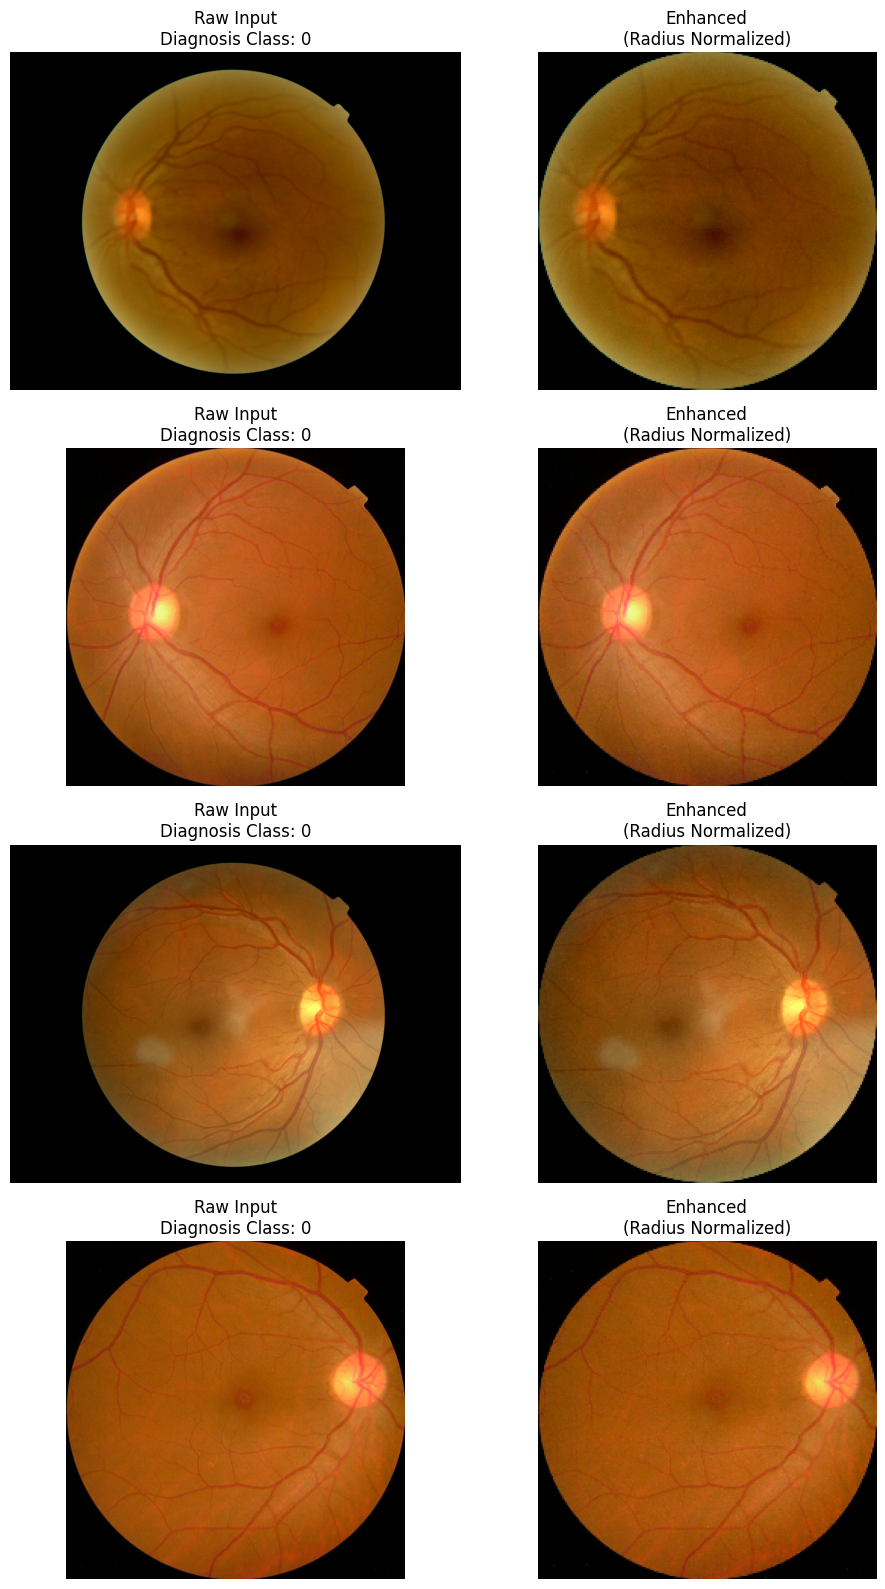

In [9]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

def visualize_preprocessing_impact(df, num_samples=3):
    """
    Randomly selects images from the dataframe and plots the
    Vanilla (Raw) vs. Enhanced (Radius Normalization + CLAHE) versions.
    """
    # Randomly sample images to get a varied look
    sample_df = df.sample(n=num_samples)

    # Set up the plotting grid
    plt.figure(figsize=(10, 4 * num_samples))

    for i, (_, row) in enumerate(sample_df.iterrows()):
        # 1. Load the raw image
        img_path = row['image_path']
        raw_img = cv2.imread(img_path)

        # OpenCV loads as BGR, convert to RGB for accurate display
        raw_img = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)

        # 2. Apply your custom enhancement pipeline
        enhanced_img = enhance_retinal_image(raw_img)

        # Matplotlib expects float arrays to be scaled between 0 and 1
        if enhanced_img.dtype == np.float32:
            display_enhanced = np.clip(enhanced_img / 255.0, 0, 1)
        else:
            display_enhanced = enhanced_img

        # Plot Raw (Left Side)
        plt.subplot(num_samples, 2, 2*i + 1)
        plt.imshow(raw_img)
        plt.title(f"Raw Input\nDiagnosis Class: {row['diagnosis']}")
        plt.axis('off')

        # Plot Enhanced (Right Side)
        plt.subplot(num_samples, 2, 2*i + 2)
        plt.imshow(display_enhanced)
        # plt.title(f"Enhanced\n(Radius Normalized + CLAHE)")
        plt.title(f"Enhanced\n(Radius Normalized)")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Execute the function using your existing dataframe
visualize_preprocessing_impact(train_df, num_samples=4)

# Dataset batch generation

In [10]:
# datagen = ImageDataGenerator(rescale=1./255)
datagen = ImageDataGenerator(
    preprocessing_function=enhance_retinal_image,
    rescale=1./255
)

# datagen = ImageDataGenerator(
#     preprocessing_function=enhance_retinal_image,
#     rescale=1./255,
#     rotation_range=20,
#     width_shift_range=0.2,
#     height_shift_range=0.2,
#     shear_range=0.2,
#     zoom_range=0.2,
#     horizontal_flip=True,
#     fill_mode='nearest'
#     )

In [11]:
train_batches = datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='image_path',
    y_col='diagnosis',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)
val_batches = datagen.flow_from_dataframe(
    dataframe=valid_df,
    x_col='image_path',
    y_col='diagnosis',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)
test_batches = datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='image_path',
    y_col='diagnosis',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 2930 validated image filenames belonging to 5 classes.
Found 366 validated image filenames belonging to 5 classes.
Found 366 validated image filenames belonging to 5 classes.


### Verify Preprocessing on a Sample Batch

Shape of images in a batch: (32, 224, 224, 3)
Shape of labels in a batch: (32, 5)


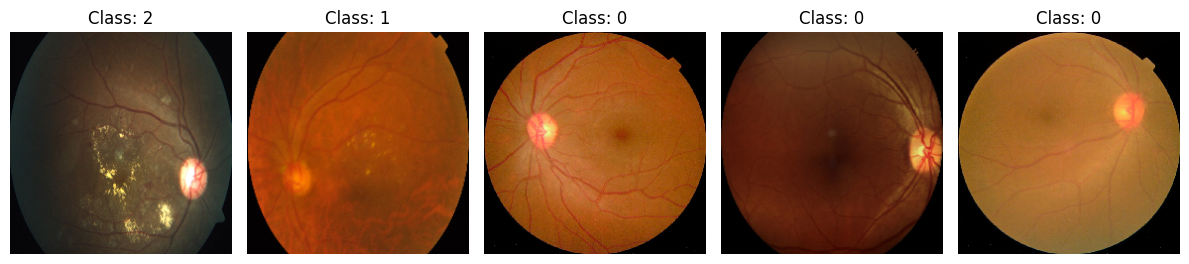

If the images above appear cropped and enhanced, your `enhance_retinal_image` function is working correctly with the `ImageDataGenerator`.


In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Get one batch of images and labels from the training generator
sample_images, sample_labels = next(train_batches)

print(f"Shape of images in a batch: {sample_images.shape}")
print(f"Shape of labels in a batch: {sample_labels.shape}")

# Display a few images from the batch
plt.figure(figsize=(12, 8))
for i in range(min(5, sample_images.shape[0])):
    plt.subplot(1, 5, i + 1)
    # ImageDataGenerator rescales to [0,1], so no need to divide by 255
    plt.imshow(sample_images[i])
    # Convert one-hot encoded label back to class index for display
    diagnosis_class = np.argmax(sample_labels[i])
    plt.title(f"Class: {diagnosis_class}")
    plt.axis('off')
plt.tight_layout()
plt.show()

print("If the images above appear cropped and enhanced, your `enhance_retinal_image` function is working correctly with the `ImageDataGenerator`.")

# Dataset Distribution

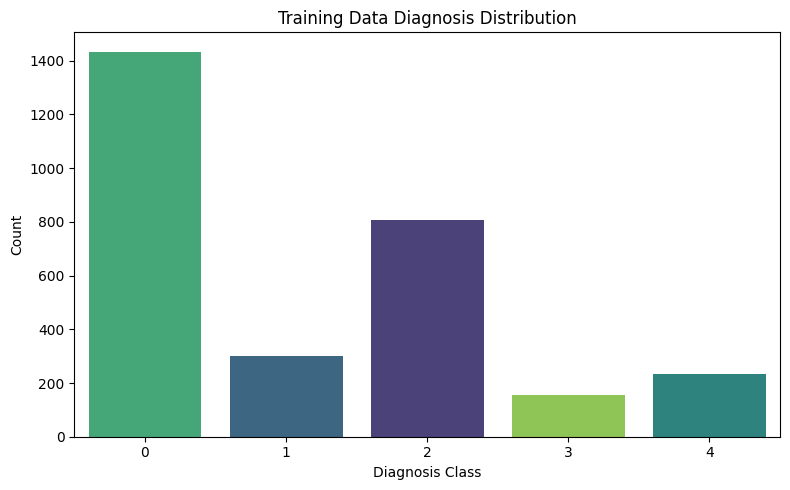

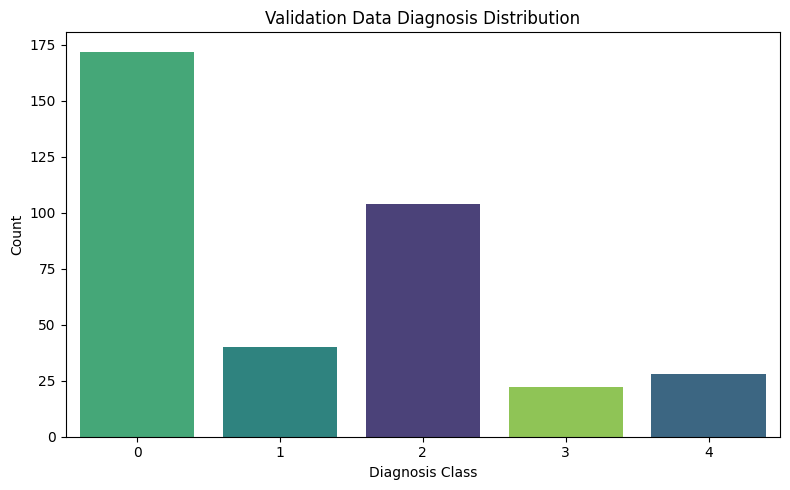

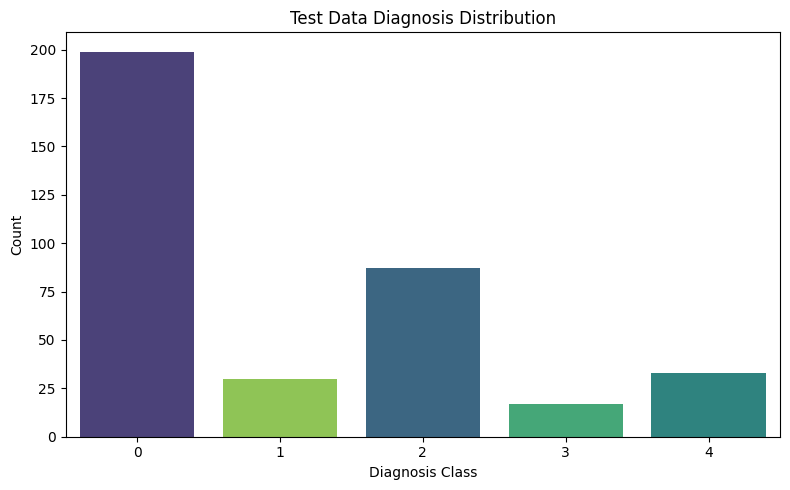

Diagnosis distribution in training data:
 diagnosis
0    1434
2     808
1     300
4     234
3     154
Name: count, dtype: int64

Diagnosis distribution in validation data:
 diagnosis
0    172
2    104
1     40
4     28
3     22
Name: count, dtype: int64

Diagnosis distribution in test data:
 diagnosis
0    199
2     87
4     33
1     30
3     17
Name: count, dtype: int64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the order for the diagnosis classes
class_order = ['0', '1', '2', '3', '4']

# Create a list of dataframes, titles, and filenames
datasets = [
    (train_df, 'Training Data Diagnosis Distribution', '/content/drive/MyDrive/NIT_DR_Project/simple_vanilla_cnn_phase4/train_diagnosis_distribution.png'),
    (valid_df, 'Validation Data Diagnosis Distribution', '/content/drive/MyDrive/NIT_DR_Project/simple_vanilla_cnn_phase4/validation_diagnosis_distribution.png'),
    (test_df, 'Test Data Diagnosis Distribution', '/content/drive/MyDrive/NIT_DR_Project/simple_vanilla_cnn_phase4/test_diagnosis_distribution.png')
]

for df, title, filename in datasets:
    plt.figure(figsize=(8, 5))
    sns.countplot(x='diagnosis', data=df, palette='viridis', hue='diagnosis', legend=False, order=class_order)
    plt.title(title)
    plt.xlabel('Diagnosis Class')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()

print("Diagnosis distribution in training data:\n", train_df['diagnosis'].value_counts())
print("\nDiagnosis distribution in validation data:\n", valid_df['diagnosis'].value_counts())
print("\nDiagnosis distribution in test data:\n", test_df['diagnosis'].value_counts())

# class weight

In [13]:
train_df['diagnosis'].value_counts()

,count
diagnosis,
0,1434
2,808
1,300
4,234
3,154


In [14]:
from sklearn.utils import class_weight
import numpy as np

# Get the class labels from the training dataframe
y_train_labels = train_df['diagnosis'].astype(int).values

# Get unique classes and their counts
classes = np.unique(y_train_labels)

# Calculate class weights
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train_labels
)

# Create a dictionary to map class index to weight
class_weight_dict = dict(zip(classes, class_weights))

print("Calculated Class Weights:")
print(class_weight_dict)

Calculated Class Weights:
{np.int64(0): np.float64(0.4086471408647141), np.int64(1): np.float64(1.9533333333333334), np.int64(2): np.float64(0.7252475247524752), np.int64(3): np.float64(3.8051948051948052), np.int64(4): np.float64(2.5042735042735043)}


# Model Definition

In [ ]:
def get_vanilla_cnn(input_shape=(224, 224, 3), num_classes=NUM_CLASS):
    model = models.Sequential([
        # block 1
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),

        # block 2
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        # block 3
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        # layers.Conv2D(128, (3, 3), use_bias=False, kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        # layers.BatchNormalization(),
        # layers.Activation('relu'),
        # layers.MaxPooling2D((2, 2)),

        # Block 4
        layers.Conv2D(256, (3,3), activation='relu'),
        layers.MaxPooling2D((2,2)),
        # layers.Conv2D(256, (3,3), use_bias=False, kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        # layers.BatchNormalization(),
        # layers.Activation('relu'),
        # layers.MaxPooling2D((2,2)),

        # flatten
        layers.Flatten(),

        # dense layers
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5),
        # layers.Dense(512, use_bias=False, kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        # layers.BatchNormalization(),
        # layers.Activation('relu'),
        # layers.Dropout(0.6), # Increased dropout rate

        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        # layers.Dense(256, use_bias=False, kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        # layers.BatchNormalization(),
        # layers.Activation('relu'),
        # layers.Dropout(0.6), # Increased dropout rate

        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),

        layers.Dense(num_classes, activation='softmax')
        # layers.Dense(num_classes, activation='softmax', kernel_regularizer=tf.keras.regularizers.l2(0.001))
    ])
    return model

# Initialize and compile
model = get_vanilla_cnn()
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy','recall'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 512)            │    18,874,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,428,165 (74.11 MB)

 Trainable params: 19,428,165 (74.11 MB)

 Non-trainable params: 0 (0.00 B)

# Model training

In [15]:
CHECKPOINT_SAVE_PATH = '/content/drive/MyDrive/NIT_DR_Project/simple_vanilla_cnn_phase4/checkpoint/checkpoint_simple_vanilla_cnn.keras'

In [17]:
from tensorflow.keras.callbacks import CSVLogger

In [18]:
csv_logger = CSVLogger('/content/drive/MyDrive/NIT_DR_Project/simple_vanilla_cnn_phase4/epoch_log.csv', append=True, separator=';')

In [19]:
callbacks = [
    # try val_recall on modelcheckpoint
    ModelCheckpoint(filepath= CHECKPOINT_SAVE_PATH, save_best_only=True, monitor='val_accuracy', mode='max', verbose=1),
    # try val_recall on earlystopping
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-4, verbose=1),
    csv_logger
]

In [ ]:
# training the model
history = model.fit(
    train_batches,
    validation_data = val_batches,
    epochs = 20,
    verbose = 1,
    callbacks = callbacks,
    class_weight = class_weight_dict
)

Epoch 1/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.3383 - loss: 1.6624 - recall: 0.1021
Epoch 1: val_accuracy improved from 0.28415 to 0.43443, saving model to /content/drive/MyDrive/NIT_DR_Project/simple_vanilla_cnn_preprocessing_phase4/checkpoint/checkpoint_simple_vanilla_cnn.keras

Epoch 1: finished saving model to /content/drive/MyDrive/NIT_DR_Project/simple_vanilla_cnn_preprocessing_phase4/checkpoint/checkpoint_simple_vanilla_cnn.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 457s 5s/step - accuracy: 0.4201 - loss: 1.5310 - recall: 0.2099 - val_accuracy: 0.4344 - val_loss: 1.0797 - val_recall: 0.3497 - learning_rate: 0.0010
Epoch 2/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5184 - loss: 1.4051 - recall: 0.3077
Epoch 2: val_accuracy did not improve from 0.43443
92/92 ━━━━━━━━━━━━━━━━━━━━ 435s 5s/step - accuracy: 0.5007 - loss: 1.3999 - recall: 0.3191 - val_accuracy: 0.4344 - val_loss: 1.0250 - val_recall: 0.3579 - learning_rate: 0.0010
Epoch 3/20
92/92 ━━━━━━━━━━━━━━━━━━━

In [ ]:
model.save("/content/drive/MyDrive/NIT_DR_Project/simple_vanilla_cnn_phase4/dr_simple_vanilla_cnn_phase4.keras")

In [ ]:
history_df = pd.DataFrame(history.history)
history_df.to_csv("/content/drive/MyDrive/NIT_DR_Project/simple_vanilla_cnn_phase4/dr_simple_vanilla_cnn_phase4_history.csv")

# loading the model for few more epochs training

In [21]:
from keras.models import load_model
model_retrain = load_model("/content/drive/MyDrive/NIT_DR_Project/simple_vanilla_cnn_phase4/checkpoint/checkpoint_simple_vanilla_cnn.keras")

In [22]:
# training the model
history_retrain = model_retrain.fit(
    train_batches,
    validation_data = val_batches,
    epochs = 20,
    verbose = 1,
    callbacks = callbacks,
    class_weight = class_weight_dict
)

Epoch 1/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 19s/step - accuracy: 0.6755 - loss: 1.1240 - recall: 0.4719 
Epoch 1: val_accuracy improved from None to 0.65301, saving model to /content/drive/MyDrive/NIT_DR_Project/simple_vanilla_cnn_phase4/checkpoint/checkpoint_simple_vanilla_cnn.keras

Epoch 1: finished saving model to /content/drive/MyDrive/NIT_DR_Project/simple_vanilla_cnn_phase4/checkpoint/checkpoint_simple_vanilla_cnn.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 2024s 22s/step - accuracy: 0.6676 - loss: 1.1452 - recall: 0.4686 - val_accuracy: 0.6530 - val_loss: 0.8765 - val_recall: 0.4262 - learning_rate: 1.0000e-04
Epoch 2/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.6728 - loss: 1.1616 - recall: 0.4579
Epoch 2: val_accuracy improved from 0.65301 to 0.66667, saving model to /content/drive/MyDrive/NIT_DR_Project/simple_vanilla_cnn_phase4/checkpoint/checkpoint_simple_vanilla_cnn.keras

Epoch 2: finished saving model to /content/drive/MyDrive/NIT_DR_Project/simple_vanilla_cnn_phase4/checkp

In [24]:
# history
history_df_retrain = pd.DataFrame(history_retrain.history)
history_df_retrain.to_csv("/content/drive/MyDrive/NIT_DR_Project/simple_vanilla_cnn_phase4/dr_simple_vanilla_cnn_phase4_retrained_history.csv")

# Epoch training result

In [25]:
history_df = pd.read_csv("/content/drive/MyDrive/NIT_DR_Project/simple_vanilla_cnn_phase4/dr_simple_vanilla_cnn_phase4_retrained_history.csv")
history_df

,Unnamed: 0,accuracy,loss,recall,val_accuracy,val_loss,val_recall,learning_rate
0,0,0.667577,1.145187,0.468601,0.653005,0.876525,0.426230,0.0001
1,1,0.663140,1.139441,0.469966,0.666667,0.924133,0.374317,0.0001
2,2,0.678498,1.119501,0.478840,0.650273,0.867797,0.437158,0.0001
3,3,0.669625,1.128589,0.470648,0.644809,0.887417,0.439891,0.0001
4,4,0.660751,1.119343,0.475768,0.680328,0.860136,0.439891,0.0001
5,5,0.672696,1.111513,0.479863,0.658470,0.849319,0.448087,0.0001
6,6,0.676109,1.090225,0.484983,0.663934,0.894498,0.456284,0.0001
7,7,0.689761,1.082036,0.497270,0.661202,0.873686,0.456284,0.0001
8,8,0.680546,1.069185,0.501706,0.677596,0.849603,0.494536,0.0001
9,9,0.688737,1.069016,0.503072,0.683060,0.882601,0.480874,0.0001


# concating history df

In [26]:
history_df = pd.read_csv('/content/drive/MyDrive/NIT_DR_Project/simple_vanilla_cnn_phase4/dr_simple_vanilla_cnn_phase4_history.csv')
history_df_retrain = pd.read_csv('/content/drive/MyDrive/NIT_DR_Project/simple_vanilla_cnn_phase4/dr_simple_vanilla_cnn_phase4_retrained_history.csv')

In [27]:
history_df_merged = pd.concat([history_df, history_df_retrain], ignore_index=True)
history_df_merged.to_csv('/content/drive/MyDrive/NIT_DR_Project/simple_vanilla_cnn_phase4/dr_simple_vanilla_cnn_phase4_history_merged.csv', index=False)

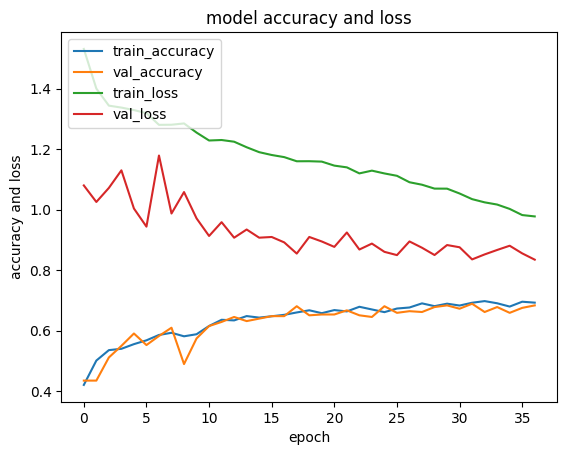

In [30]:
history_df_merged['accuracy'].plot()
history_df_merged['val_accuracy'].plot()
history_df_merged['loss'].plot()
history_df_merged['val_loss'].plot()
plt.title('model accuracy and loss')
plt.ylabel('accuracy and loss')
plt.xlabel('epoch')
plt.legend(['train_accuracy', 'val_accuracy', 'train_loss', 'val_loss'], loc='upper left')

# saving model

In [39]:
model_retrain.save("/content/drive/MyDrive/NIT_DR_Project/simple_vanilla_cnn_phase4/dr_simple_vanilla_cnn_phase4_retrained.keras")

# Val_accuacy & train_accuracy line chart

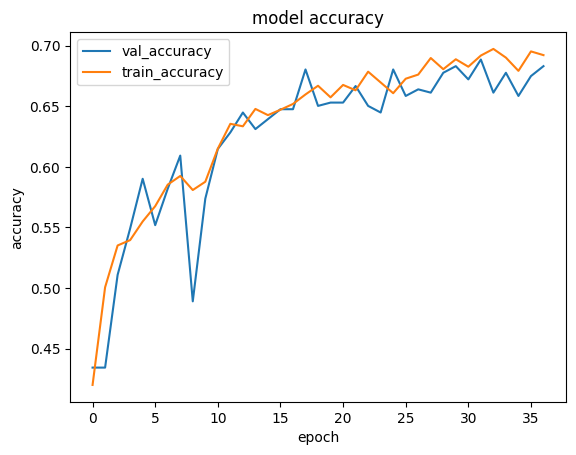

In [31]:
# plot val_accuracy and train_accuracy
import matplotlib.pyplot as plt
plt.plot(history_df_merged['val_accuracy'])
plt.plot(history_df_merged['accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['val_accuracy', 'train_accuracy'], loc='upper left')
plt.savefig('/content/drive/MyDrive/NIT_DR_Project/simple_vanilla_cnn_phase4/simple_vanilla_phase4_accuracy.png')
plt.show()

# train_loss and val_loss chart

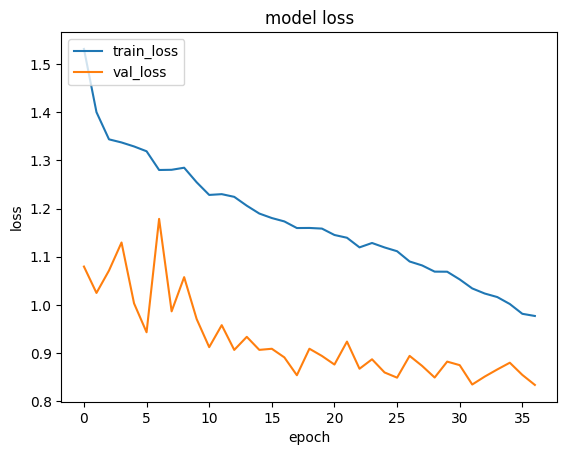

In [33]:
# plot val_loss and train_loss
plt.plot(history_df_merged['loss'])
plt.plot(history_df_merged['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train_loss', 'val_loss'], loc='upper left')
plt.savefig('/content/drive/MyDrive/NIT_DR_Project/simple_vanilla_cnn_phase4/simple_vanilla_phase4_loss.png')
plt.show()

# loading model

In [35]:
# load model
from keras.models import load_model
model = load_model("/content/drive/MyDrive/NIT_DR_Project/simple_vanilla_cnn_phase4/checkpoint/checkpoint_simple_vanilla_cnn.keras")

# Evalting Model

In [40]:
model_retrain.evaluate(test_batches)

12/12 ━━━━━━━━━━━━━━━━━━━━ 190s 17s/step - accuracy: 0.6940 - loss: 0.7886 - recall: 0.5710


[0.7885809540748596, 0.693989098072052, 0.5710382461547852]

In [41]:
model.evaluate(test_batches)

12/12 ━━━━━━━━━━━━━━━━━━━━ 58s 4s/step - accuracy: 0.6940 - loss: 0.7886 - recall: 0.5710


[0.7885809540748596, 0.693989098072052, 0.5710382461547852]

In [34]:
loss, accuracy = model.evaluate(test_batches)

NameError: name 'model' is not defined

In [ ]:
loss

In [ ]:
accuracy

# <font color="yellow">classification report</font>

In [42]:
# classification report
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
import numpy as np

In [43]:
Y_pred = model.predict(test_batches)
y_pred = np.argmax(Y_pred, axis=1)

12/12 ━━━━━━━━━━━━━━━━━━━━ 59s 5s/step


In [44]:
# classification report
print('Classification Report')
# target_names = ['class 0(0)', 'class 1(1)', 'class 2(2)', 'class 3(3)', 'class 4(4)']
print(classification_report(test_batches.classes, y_pred))

Classification Report
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       199
           1       0.30      0.67      0.41        30
           2       0.69      0.39      0.50        87
           3       0.13      0.24      0.17        17
           4       0.25      0.15      0.19        33

    accuracy                           0.69       366
   macro avg       0.47      0.48      0.45       366
weighted avg       0.74      0.69      0.70       366



# <font color="yellow">tabulated classification report</font>


In [45]:
import pandas as pd
from sklearn.metrics import classification_report

# Generate the classification report as a dictionary
report = classification_report(test_batches.classes, y_pred, output_dict=True)

# Convert the report dictionary to a pandas DataFrame
df_report = pd.DataFrame(report).transpose()

# Save the DataFrame to a CSV file
report_filepath = '/content/drive/MyDrive/NIT_DR_Project/simple_vanilla_cnn_phase4/classification_report.csv'
df_report.to_csv(report_filepath)

print(f"Classification report saved to: {report_filepath}")
display(df_report)

Classification report saved to: /content/drive/MyDrive/NIT_DR_Project/simple_vanilla_cnn_phase4/classification_report.csv


,precision,recall,f1-score,support
0,0.959799,0.959799,0.959799,199.000000
1,0.298507,0.666667,0.412371,30.000000
2,0.693878,0.390805,0.500000,87.000000
3,0.129032,0.235294,0.166667,17.000000
4,0.250000,0.151515,0.188679,33.000000
accuracy,0.693989,0.693989,0.693989,0.693989
macro avg,0.466243,0.480816,0.445503,366.000000
weighted avg,0.739798,0.693989,0.699265,366.000000


In [46]:
from sklearn.metrics import recall_score

# Calculate macro-averaged recall
macro_recall_score = recall_score(test_batches.classes, y_pred, average='macro')
print(f"Macro-averaged Recall: {macro_recall_score:.4f}")

Macro-averaged Recall: 0.4808


In [47]:
df_report_styled = df_report.style.background_gradient(cmap='viridis')
display(df_report_styled)

,precision,recall,f1-score,support
0,0.959799,0.959799,0.959799,199.000000
1,0.298507,0.666667,0.412371,30.000000
2,0.693878,0.390805,0.500000,87.000000
3,0.129032,0.235294,0.166667,17.000000
4,0.250000,0.151515,0.188679,33.000000
accuracy,0.693989,0.693989,0.693989,0.693989
macro avg,0.466243,0.480816,0.445503,366.000000
weighted avg,0.739798,0.693989,0.699265,366.000000


## <font color = 'yellow'>Confusion Matrix</font>

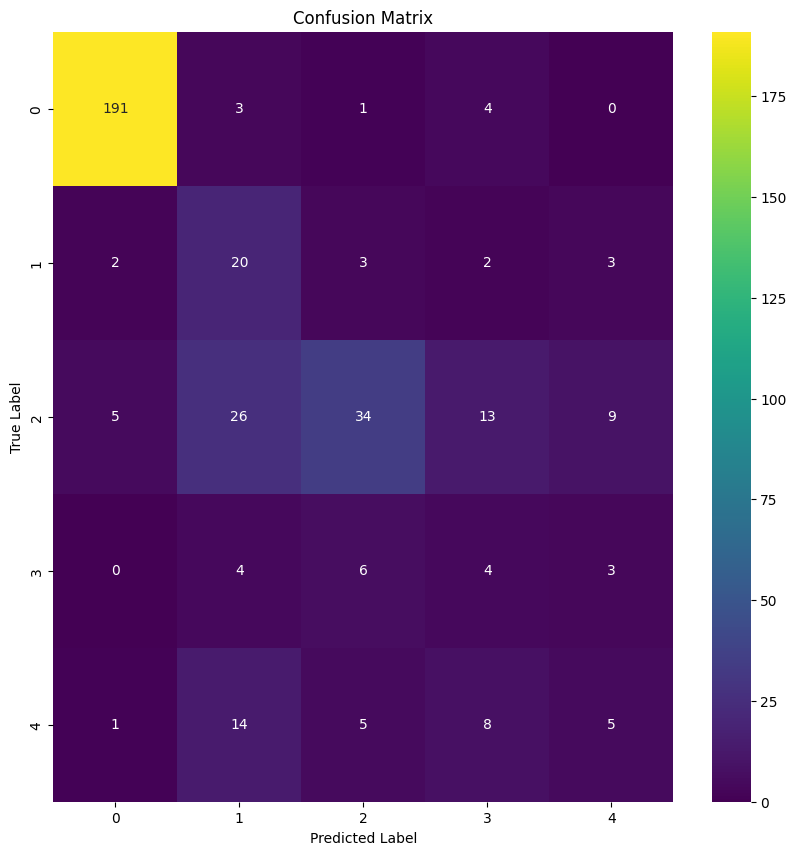

In [49]:
# confusion matrix
import seaborn as sns
cm = confusion_matrix(test_batches.classes, y_pred)
plt.figure(figsize=(10, 10))
sns.heatmap(cm, annot=True, cmap = 'viridis', fmt='d', xticklabels=[0, 1, 2, 3, 4], yticklabels=[0, 1, 2, 3, 4])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig('/content/drive/MyDrive/NIT_DR_Project/simple_vanilla_cnn_phase4/simple_vanilla_phase4_confusion_matrix.png')
plt.show()

## <font color = 'yellow'>Normalised Confusion Matrix</font>

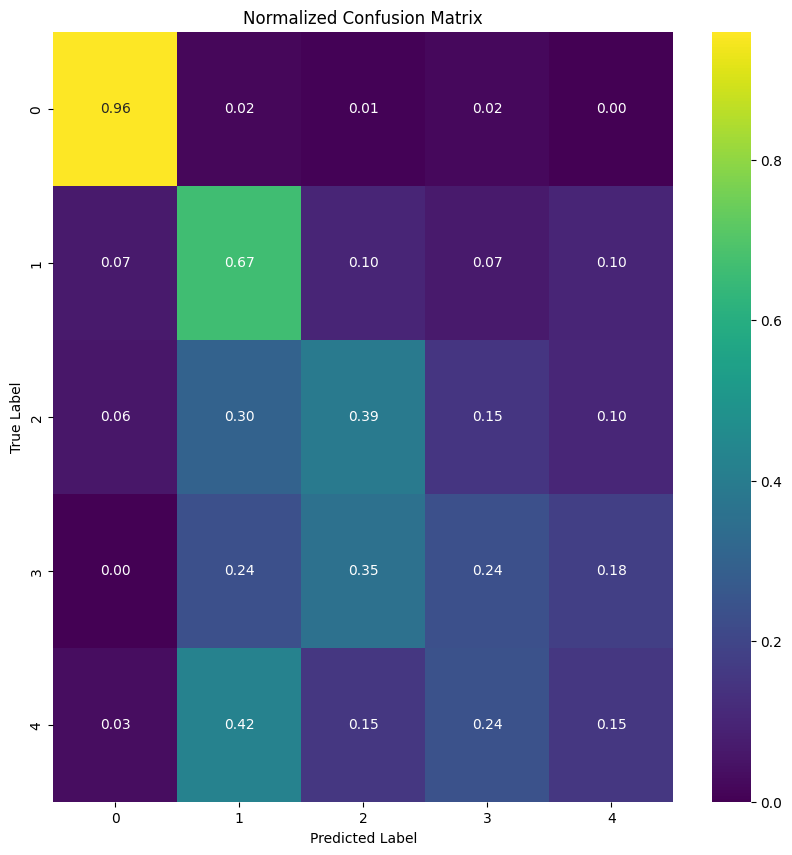

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Normalize the confusion matrix
# Divide each row by the sum of the row to get percentages
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 10))
sns.heatmap(cm_normalized, annot=True, cmap='viridis', fmt='.2f', xticklabels=np.arange(NUM_CLASS), yticklabels=np.arange(NUM_CLASS))
plt.title('Normalized Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig('/content/drive/MyDrive/NIT_DR_Project/simple_vanilla_cnn_phase4/simple_vanilla_normalized_confusion_matrix.png')
plt.show()

# <font color='yellow'>Model Architrecture</font>

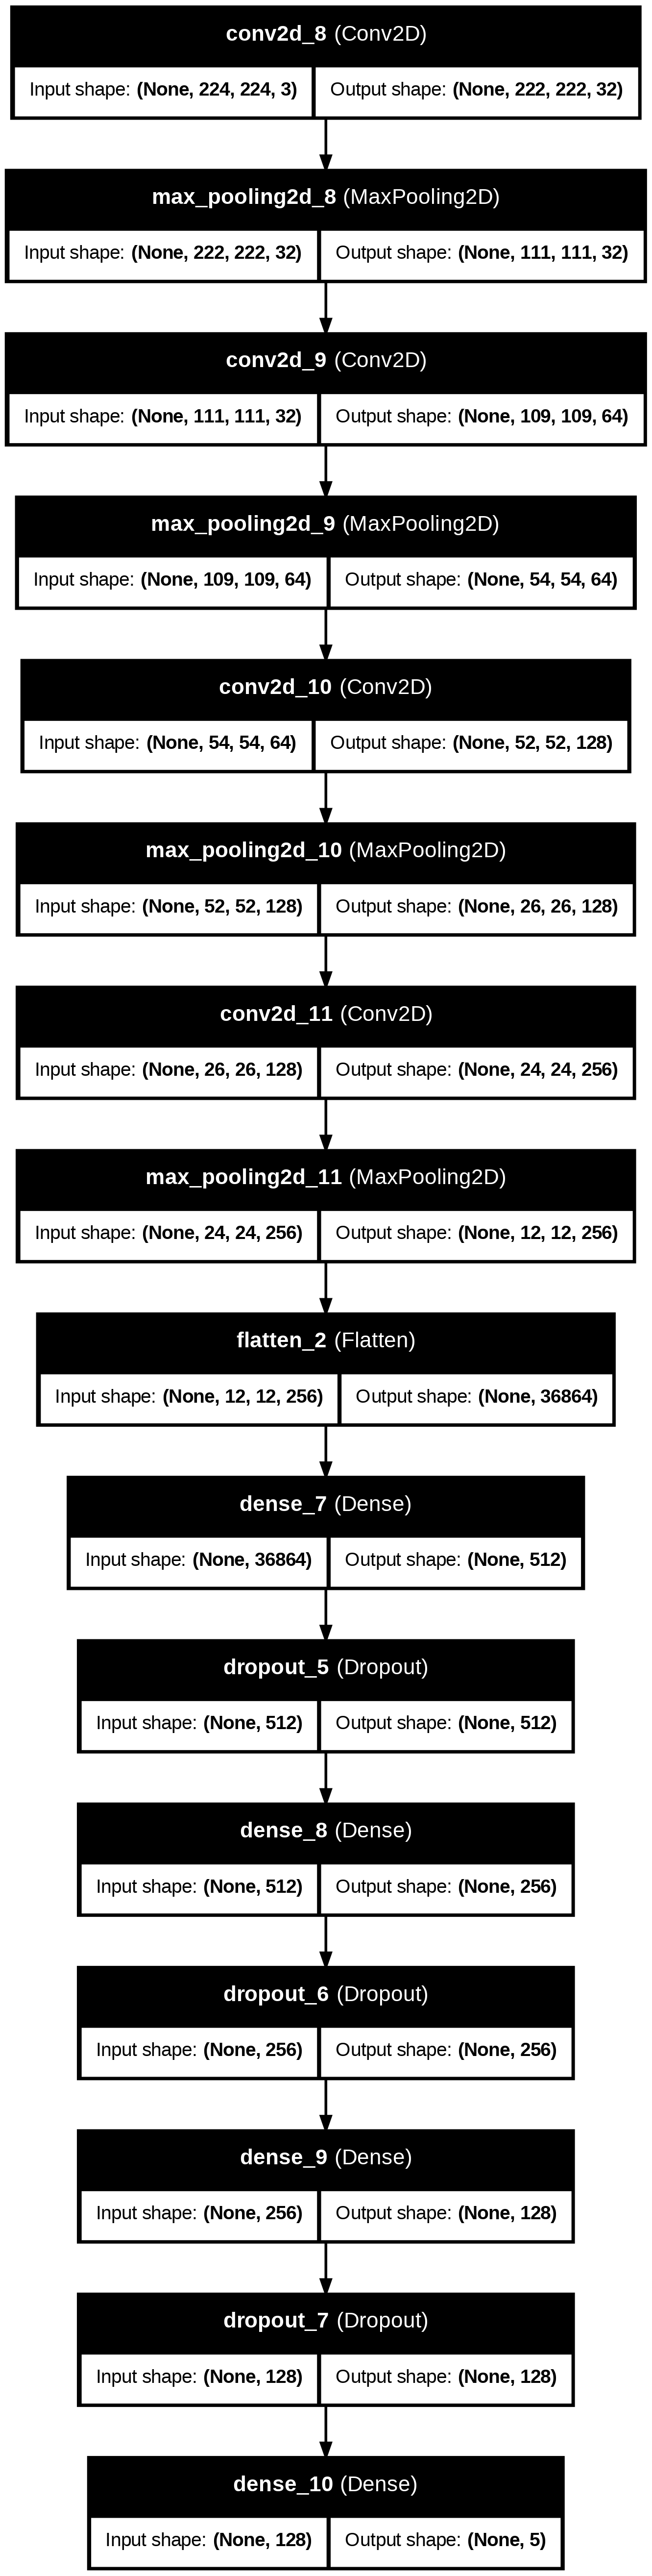

In [51]:
from tensorflow.keras.utils import plot_model

# 'model' is your compiled Keras model
plot_model(model, to_file='/content/drive/MyDrive/NIT_DR_Project/simple_vanilla_cnn_phase4/model_architecture.png', show_shapes=True, show_layer_names=True)